# UnitMatch Quality Control Analysis

This notebook analyzes the output of the UnitMatch pipeline (sliding window batches). 
It aims to visualize:
1. **Stability**: How long are neurons tracked?
2. **Attrition**: How many neurons are lost between sessions?
3. **Quality**: Are there signs of over-merging?

## 1. Imports and Setup

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setup paths
repo_root = Path("..").resolve()  # Assuming running from notebooks/
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

# Old UnitMatch batch output (still needed for per-batch analysis & waveform lookup)
data_root = repo_root / "data" / "unit_match" / "output" / "BG_046"

# DeepUnitMatch global output
deep_um_root = repo_root / "data" / "deep_unit_match" / "output" / "BG_046"


def _parse_date(s):
    """Parse a DDMMYYYY directory name, handling missing leading zero on day."""
    s = str(s)
    if len(s) == 7:
        s = '0' + s
    return pd.to_datetime(s, format='%d%m%Y')


print(f"Old UnitMatch batches: {data_root}")
print(f"DeepUnitMatch output:  {deep_um_root}")

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

Old UnitMatch batches: E:\python_analysis\git_repos\vis_detect_analysis_Sep2025\data\unit_match\output\BG_046
DeepUnitMatch output:  E:\python_analysis\git_repos\vis_detect_analysis_Sep2025\data\deep_unit_match\output\BG_046


## 2. Load Registry Data

We scan all subfolders for `CellRegistry.csv` files and compile the statistics.

In [2]:
registry_files = sorted(list(data_root.rglob("CellRegistry.csv")))
print(f"Found {len(registry_files)} registry files.")

batch_stats = []
all_track_lengths = []

for p in registry_files:
    # Parse Batch Name
    batch_name = p.parent.name
    try:
        # Load
        df = pd.read_csv(p, index_col=0)
        
        # Calculate Metrics
        total_units = len(df)
        lengths = df.count(axis=1) # Non-null entries per row
        
        # Check for merges (semicolons)
        has_merge = df.apply(lambda x: x.astype(str).str.contains(';').any(), axis=1)
        merge_rate = has_merge.sum() / total_units * 100
        
        # Survival (units present in > 50% of sessions)
        # Assuming 12 sessions per batch usually
        n_sessions = df.shape[1]
        stable_units = (lengths > (n_sessions / 2)).sum()
        stable_rate = stable_units / total_units * 100
        
        # Store for plotting
        batch_stats.append({
            'Batch': batch_name,
            'Total_Units': total_units,
            'Merge_Rate_Pct': merge_rate,
            'Stable_Rate_Pct': stable_rate,
            'Max_Duration': lengths.max()
        })
        
        # Store raw lengths for histogram
        batch_lengths = pd.DataFrame({'Length': lengths, 'Batch': batch_name})
        all_track_lengths.append(batch_lengths)
        
    except Exception as e:
        print(f"Error reading {batch_name}: {e}")

df_stats = pd.DataFrame(batch_stats)
df_lengths = pd.concat(all_track_lengths, ignore_index=True)

df_stats.head()

Found 31 registry files.


,Batch,Total_Units,Merge_Rate_Pct,Stable_Rate_Pct,Max_Duration
0,01092025_to_05082025,1731,1.964183,1.502022,10
1,02092025_to_12082025,1683,2.198455,1.604278,11
2,03092025_to_13082025,1714,2.392065,1.400233,11
3,04082025_to_04072025,1086,2.117864,0.552486,9
4,04092025_to_14082025,1685,2.195846,1.305638,11


## 3. Visualization

### A. Track Length Distribution
How many sessions do neurons typically last?

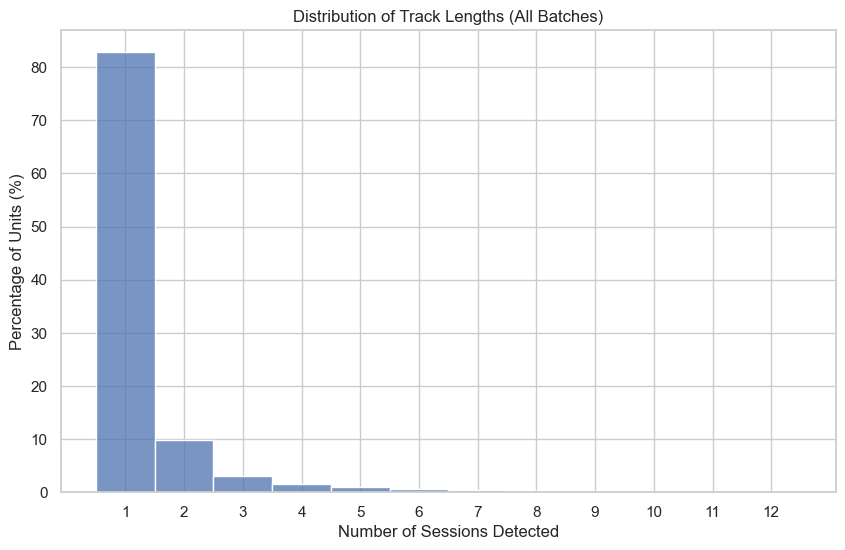

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_lengths, x="Length", discrete=True, stat="percent")
plt.title("Distribution of Track Lengths (All Batches)")
plt.xlabel("Number of Sessions Detected")
plt.ylabel("Percentage of Units (%)")
plt.xticks(range(1, 13))
plt.show()

### B. Stability Over Time
Does the tracking quality vary across the experiment? (e.g. is the rig more stable in some weeks?)

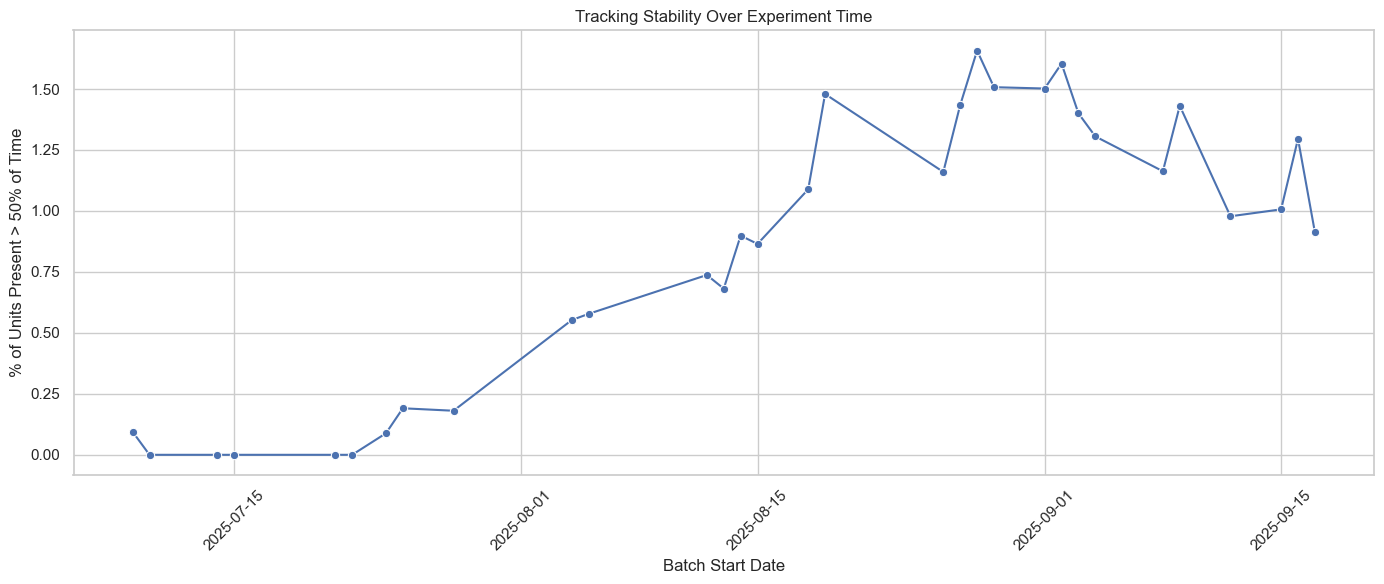

In [4]:
# We need to sort batches chronologically to make sense of "Time"
# Parse date strings from batch names "DDMMYYYY_to_DDMMYYYY"

def parse_start_date(batch_str):
    try:
        start_str = batch_str.split('_to_')[0]
        return pd.to_datetime(start_str, format="%d%m%Y")
    except:
        return pd.Timestamp.min

df_stats['StartDate'] = df_stats['Batch'].apply(parse_start_date)
df_stats = df_stats.sort_values('StartDate')

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_stats, x='StartDate', y='Stable_Rate_Pct', marker='o')
plt.title("Tracking Stability Over Experiment Time")
plt.xlabel("Batch Start Date")
plt.ylabel("% of Units Present > 50% of Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### C. Merge Rate
Are we seeing excessive merging (e.g. multiple Kilosort clusters assigned to 1 Neuron)?
A low rate (<5%) is good. A high rate (>20%) implies over-clustering in Kilosort or over-merging in UnitMatch.

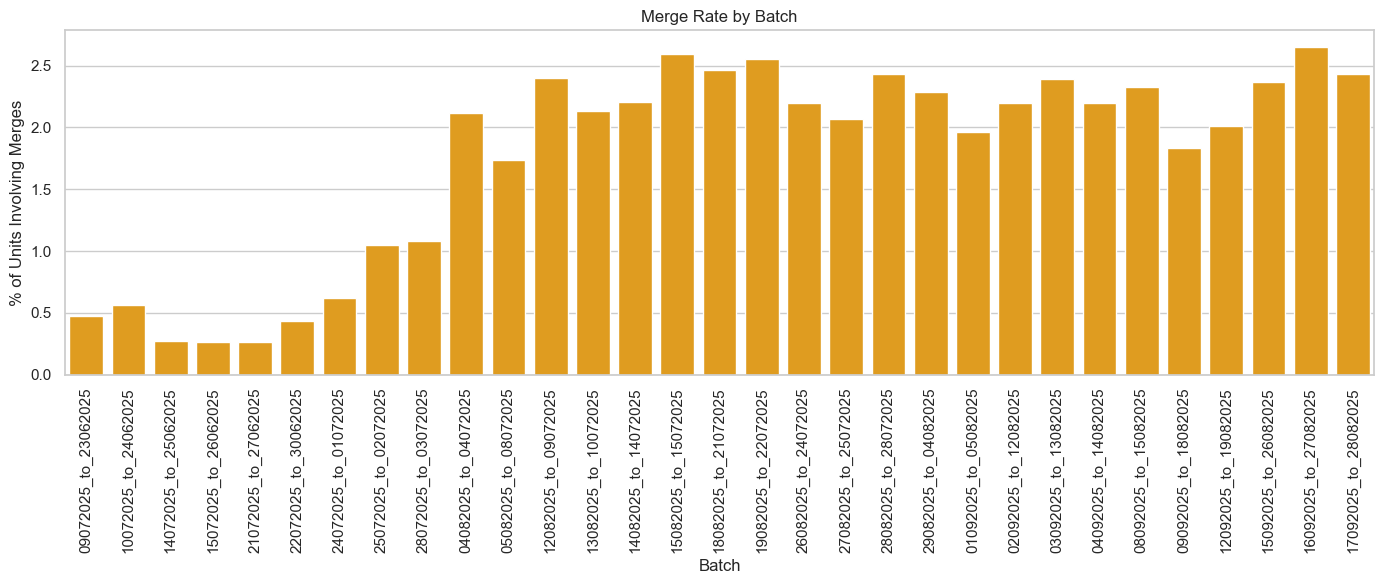

In [5]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_stats, x='Batch', y='Merge_Rate_Pct', color='orange')
plt.title("Merge Rate by Batch")
plt.xticks(rotation=90)
plt.ylabel("% of Units Involving Merges")
plt.tight_layout()
plt.show()

## 4. Explore "Golden Units" (The Best Tracked Neurons)
Let's find the best batch and look at some example stable neurons.

In [6]:
# Find batch with highest stability
best_batch_row = df_stats.loc[df_stats['Stable_Rate_Pct'].idxmax()]
print(f"Best Batch: {best_batch_row['Batch']} (Stable Rate: {best_batch_row['Stable_Rate_Pct']:.2f}%)")

# Load that batch
best_reg_path = data_root / best_batch_row['Batch'] / "CellRegistry.csv"
df_best = pd.read_csv(best_reg_path, index_col=0)

# Filter for units present in ALL sessions
n_sessions = df_best.shape[1]
track_lengths = df_best.count(axis=1)
golden_units = df_best[track_lengths == n_sessions]

print(f"Found {len(golden_units)} 'Golden Units' tracked across all {n_sessions} sessions in this batch.")

if not golden_units.empty:
    print("\nExample Golden Unit Map:")
    # Show first 5
    display(golden_units.head())
else:
    print("No perfect tracks found. Showing longest matches:")
    longest = track_lengths.max()
    display(df_best[track_lengths == longest].head())

Best Batch: 28082025_to_28072025 (Stable Rate: 1.66%)
Found 0 'Golden Units' tracked across all 12 sessions in this batch.
No perfect tracks found. Showing longest matches:


,28082025,27082025,26082025,19082025,18082025,15082025,14082025,13082025,12082025,05082025,04082025,28072025
UID,,,,,,,,,,,,
390,NaN,467,497,542,534,496;503,503;532,509;513;515,451;455;456,639,488,390;392
399,NaN,485;489,511;514,534;551;560,521;540,493;506,494,508,474;476,643,504,393


## 5. Analysis of Discontinuous Tracks (Gaps)
Sometimes a neuron is "lost" for a day (due to noise, drift, or low firing) but reappears later. 
These are **"Gappy"** tracks. 
UnitMatch can find these because it compares all sessions pairwise, not just consecutive ones.

Total Units Analyzed: 43635
Discontinuous Units: 3989 (9.14%)


C:\Users\Ben\AppData\Local\Temp\ipykernel_11432\766813180.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Track Type")


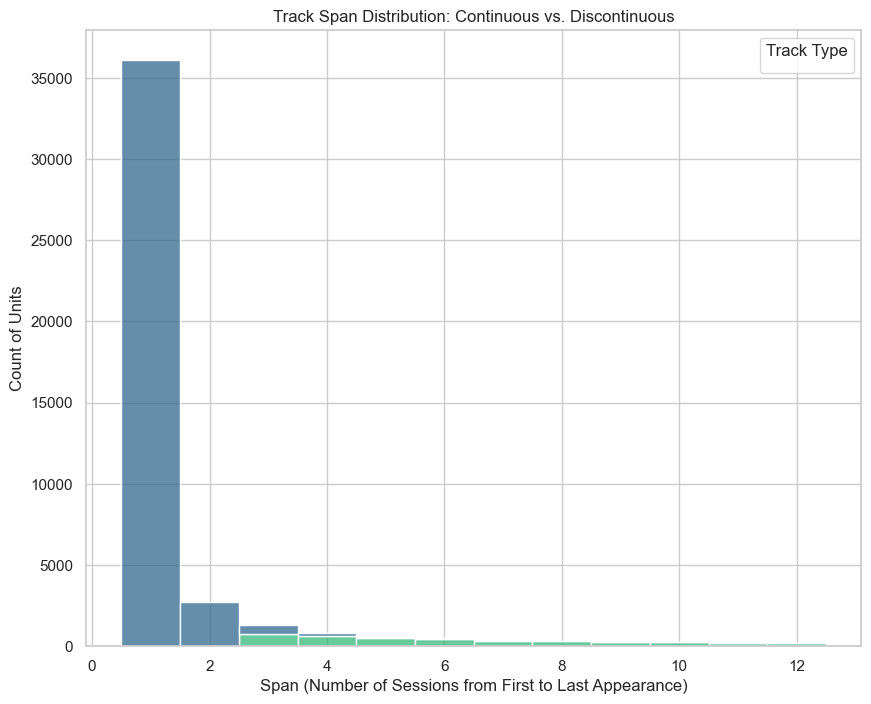

C:\Users\Ben\AppData\Local\Temp\ipykernel_11432\766813180.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=gappy_only, x='GapCount', palette='magma')


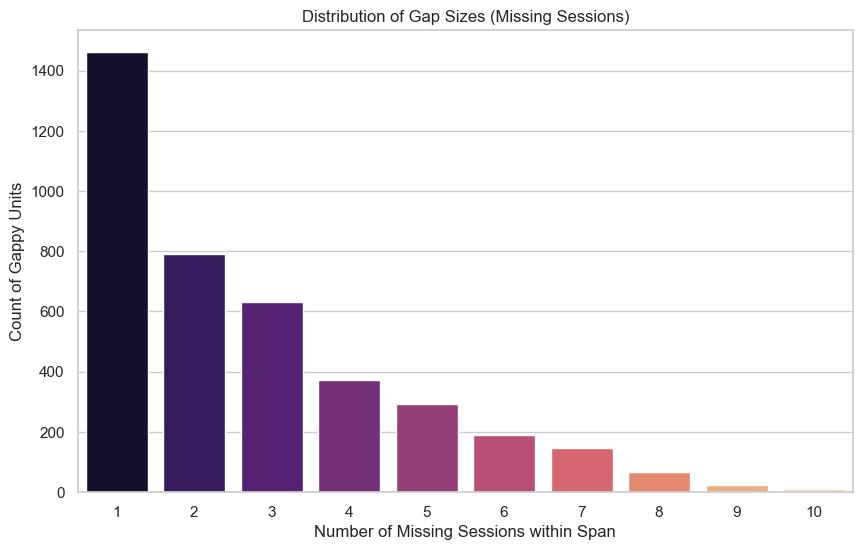

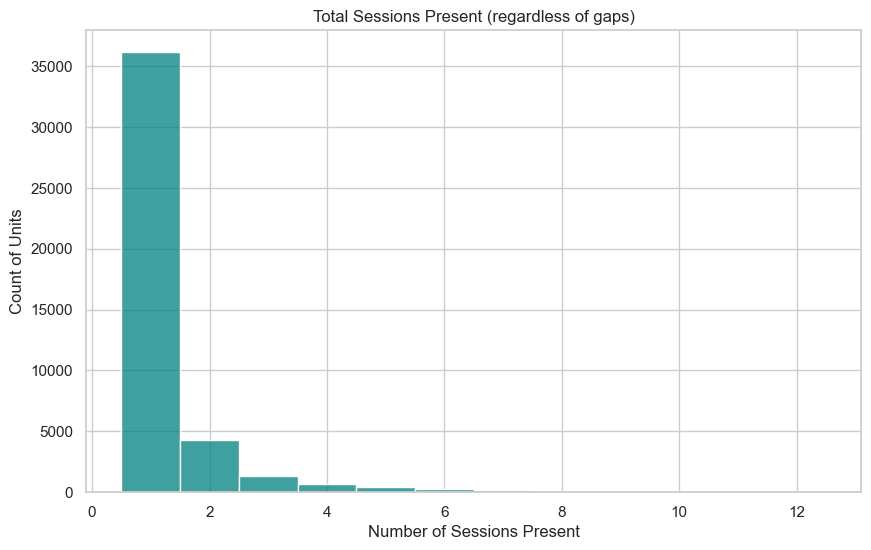

In [7]:
def get_gap_metrics(row):
    """
    Returns (Span, Presence, GapCount)
    Span: Last session index - First session index + 1
    Presence: Number of sessions detected
    GapCount: Span - Presence
    """
    present = row.notna().values
    if present.sum() == 0:
        return 0, 0, 0
        
    idx = np.where(present)[0]
    span = idx[-1] - idx[0] + 1
    presence = len(idx)
    gap_count = span - presence
    
    return pd.Series([span, presence, gap_count], index=['Span', 'Presence', 'GapCount'])

print("Collecting detailed gap statistics across all batches...")
all_unit_data = []

for p in registry_files:
    batch_name = p.parent.name
    try:
        df = pd.read_csv(p, index_col=0)
        
        # Calculate metrics for all units in this batch
        metrics = df.apply(get_gap_metrics, axis=1)
        metrics['Batch'] = batch_name
        
        all_unit_data.append(metrics)
        
    except Exception as e:
        print(f"Skipping {batch_name}: {e}")

# Combine all data
df_units = pd.concat(all_unit_data, ignore_index=True)
df_units['HasGap'] = df_units['GapCount'] > 0
df_units['Type'] = df_units['HasGap'].apply(lambda x: 'Discontinuous (Gappy)' if x else 'Continuous')

# --- Summary Statistics ---
total_units = len(df_units)
gappy_units = df_units['HasGap'].sum()
print(f"Total Units Analyzed: {total_units}")
print(f"Discontinuous Units: {gappy_units} ({gappy_units/total_units*100:.2f}%)")

# --- Visualization 1: Presence vs Span ---
# How many sessions are they present in vs how long is their span?
plt.figure(figsize=(10, 8))
sns.histplot(
    data=df_units, 
    x="Span", 
    hue="Type", 
    multiple="stack", 
    discrete=True,
    palette="viridis"
)
plt.title("Track Span Distribution: Continuous vs. Discontinuous")
plt.xlabel("Span (Number of Sessions from First to Last Appearance)")
plt.ylabel("Count of Units")
plt.legend(title="Track Type")
plt.show()

# --- Visualization 2: Gap Size Distribution ---
# For the units that have gaps, how many sessions are they missing?
gappy_only = df_units[df_units['HasGap']]
if not gappy_only.empty:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=gappy_only, x='GapCount', palette='magma')
    plt.title("Distribution of Gap Sizes (Missing Sessions)")
    plt.xlabel("Number of Missing Sessions within Span")
    plt.ylabel("Count of Gappy Units")
    plt.show()

# --- Visualization 3: Presence Distribution ---
# Just pure presence count
plt.figure(figsize=(10, 6))
sns.histplot(data=df_units, x="Presence", discrete=True, color="teal")
plt.title("Total Sessions Present (regardless of gaps)")
plt.xlabel("Number of Sessions Present")
plt.ylabel("Count of Units")
plt.show()

## 6. Global Stitching (Cross-Batch Analysis)
To identify neurons present across the entire experiment (42+ sessions), we need to stitch the overlapping 12-session batches together. 
We rely on the fact that batches overlap significantly. If `Unit A` in Batch 1 and `Unit B` in Batch 2 refer to the same Cluster ID in a shared session, they are the same neuron.

### A. Stitching Algorithm
1. Start with the first chronological batch.
2. Iteratively merge the next batch.
3. Link units based on matching Cluster IDs in shared sessions.
4. Create a master `Global_Registry`.

Loaded DeepUM Registry: 5971 units x 42 sessions


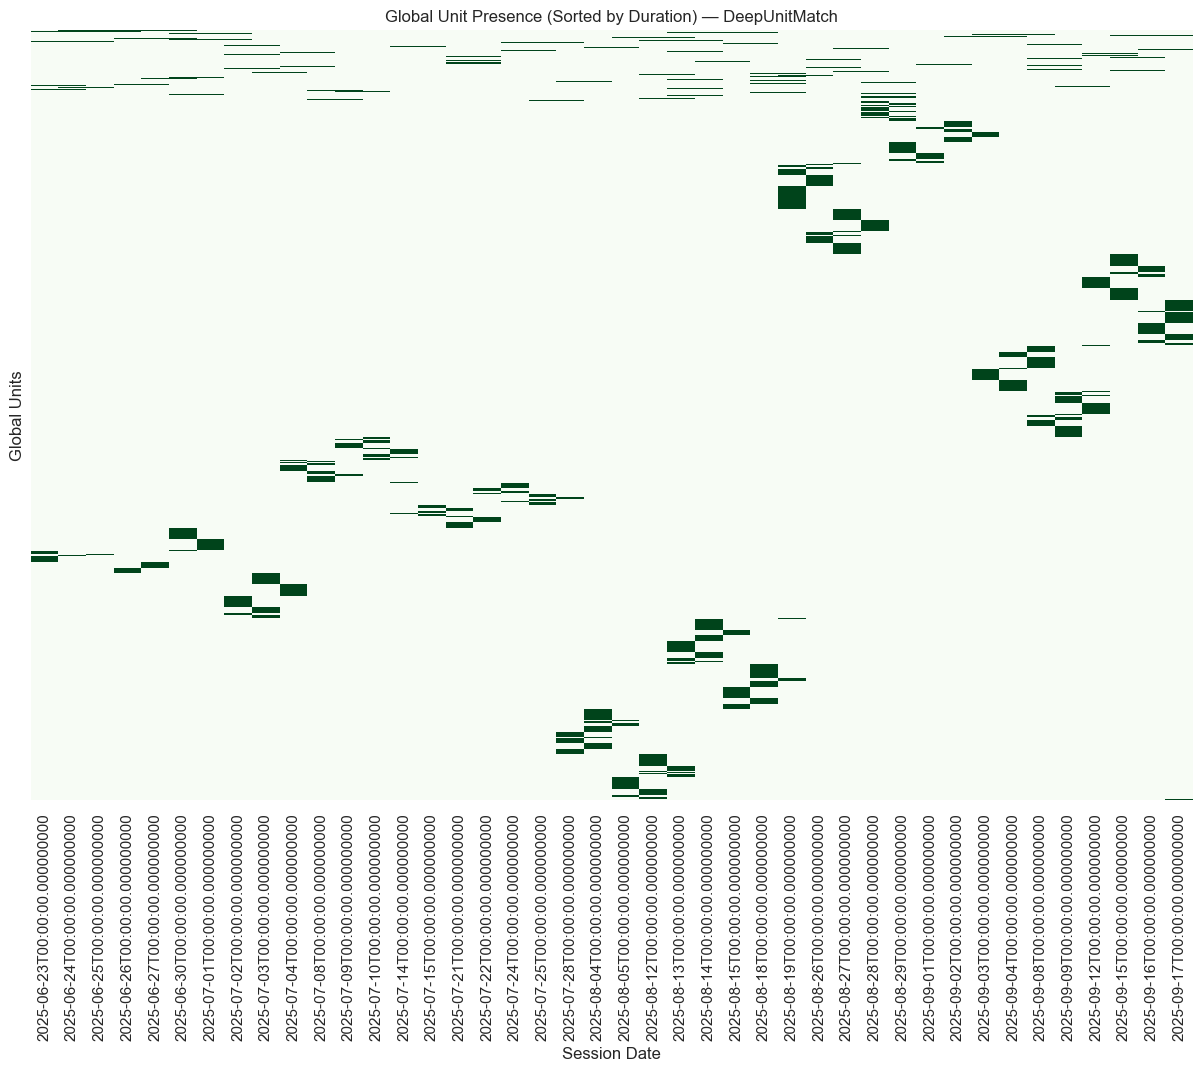

In [8]:
# Load DeepUnitMatch global registry directly
# (replaces the old stitch_registries() call which was specific to overlapping-batch UnitMatch)
registry_csv = deep_um_root / "DeepUM_CellRegistry.csv"
global_registry = pd.read_csv(registry_csv, index_col=0)

# Convert column names (DDMMYYYY strings) to datetime objects
global_registry.columns = [_parse_date(c) for c in global_registry.columns]

# Sort columns chronologically
global_registry = global_registry[sorted(global_registry.columns)]

print(f"Loaded DeepUM Registry: {global_registry.shape[0]} units x {global_registry.shape[1]} sessions")

# Visualize Global Matrix (Spy Plot)
plt.figure(figsize=(15, 10))
# Convert to boolean presence matrix
presence_matrix = global_registry.notna()
# Sort by duration
duration = presence_matrix.sum(axis=1)
sorted_indices = duration.sort_values(ascending=False).index
sorted_matrix = presence_matrix.loc[sorted_indices]

sns.heatmap(sorted_matrix, cbar=False, cmap="Greens", yticklabels=False)
plt.title("Global Unit Presence (Sorted by Duration) — DeepUnitMatch")
plt.xlabel("Session Date")
plt.ylabel("Global Units")
plt.show()

### B. Identify Top "Long-Term" Neurons
List the neurons present in the highest number of sessions.

Total Unique Global Units Identified: 5971
Total Sessions in Timeline: 42


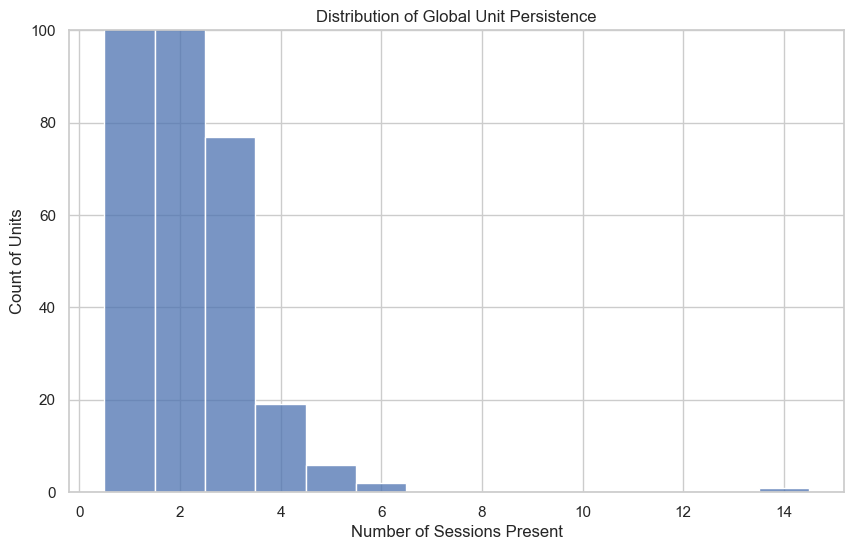


--- Top 20 Most Persistent Neurons ---


,Total_Sessions,2025-06-23,2025-06-24,2025-06-25,2025-06-26,2025-06-27
UID,,,,,,
3600,14,NaN,NaN,NaN,NaN,NaN
33,6,251.0,217.0,201.0,190.0,148.0
3774,6,NaN,NaN,NaN,NaN,NaN
238,5,NaN,NaN,NaN,NaN,NaN
3842,5,NaN,NaN,NaN,NaN,NaN
4872,5,NaN,NaN,NaN,NaN,NaN
25,5,207.0,178.0,164.0,144.0,123.0
98,5,NaN,439.0,428.0,421.0,351.0
2261,5,NaN,NaN,NaN,NaN,NaN


...(showing only first 5 session columns for brevity)...


In [9]:
# Calculate Global Stats
global_presence = global_registry.count(axis=1)
max_sessions = global_registry.shape[1]

print(f"Total Unique Global Units Identified: {len(global_registry)}")
print(f"Total Sessions in Timeline: {max_sessions}")

# Histogram of Global Duration
plt.figure(figsize=(10,6))
sns.histplot(global_presence, bins=max_sessions, discrete=True)
plt.xlabel("Number of Sessions Present")
plt.ylabel("Count of Units")
plt.title("Distribution of Global Unit Persistence")
plt.ylim(0, 100)
plt.show()

# Extract Top Neurons
top_n = 20
top_indices = global_presence.sort_values(ascending=False).head(top_n).index
top_neurons = global_registry.loc[top_indices]
top_neurons['Total_Sessions'] = global_presence.loc[top_indices]

print(f"\n--- Top {top_n} Most Persistent Neurons ---")
display(top_neurons[['Total_Sessions']].join(top_neurons.drop('Total_Sessions', axis=1).iloc[:, :5]).rename(columns=lambda x: str(x).split(' ')[0] if ' ' in str(x) else x))
print("...(showing only first 5 session columns for brevity)...")

## 7. Deep Dive Visualization of Top Neurons
To validate that these "Global Units" are indeed the same neuron over time, we will retrieve and plot their waveforms from different timepoints (e.g., First Appearance vs. Last Appearance).

**Process:**
1. Select the top persistent neurons.
2. For each neuron, identify an "Early" session and a "Late" session.
3. Locate the specific `Batch` and `UID` corresponding to these instances.
4. Extract the waveform from `WaveformInfo.npz`.
5. Overlay the waveforms to check for shape consistency.

> **Methodological Note:** The waveforms used for UnitMatch validation were computed from the **Inter-Trial Interval (ITI)** of the recording sessions. This ensures that the waveform shapes are not confounded by stimulus-evoked activity or spiking variability driven by visual inputs.

C:\Users\Ben\AppData\Local\Temp\ipykernel_11432\669534329.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize='x-small')
C:\Users\Ben\AppData\Local\Temp\ipykernel_11432\669534329.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize='x-small')
C:\Users\Ben\AppData\Local\Temp\ipykernel_11432\669534329.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize='x-small')
C:\Users\Ben\AppData\Local\Temp\ipykernel_11432\669534329.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored whe

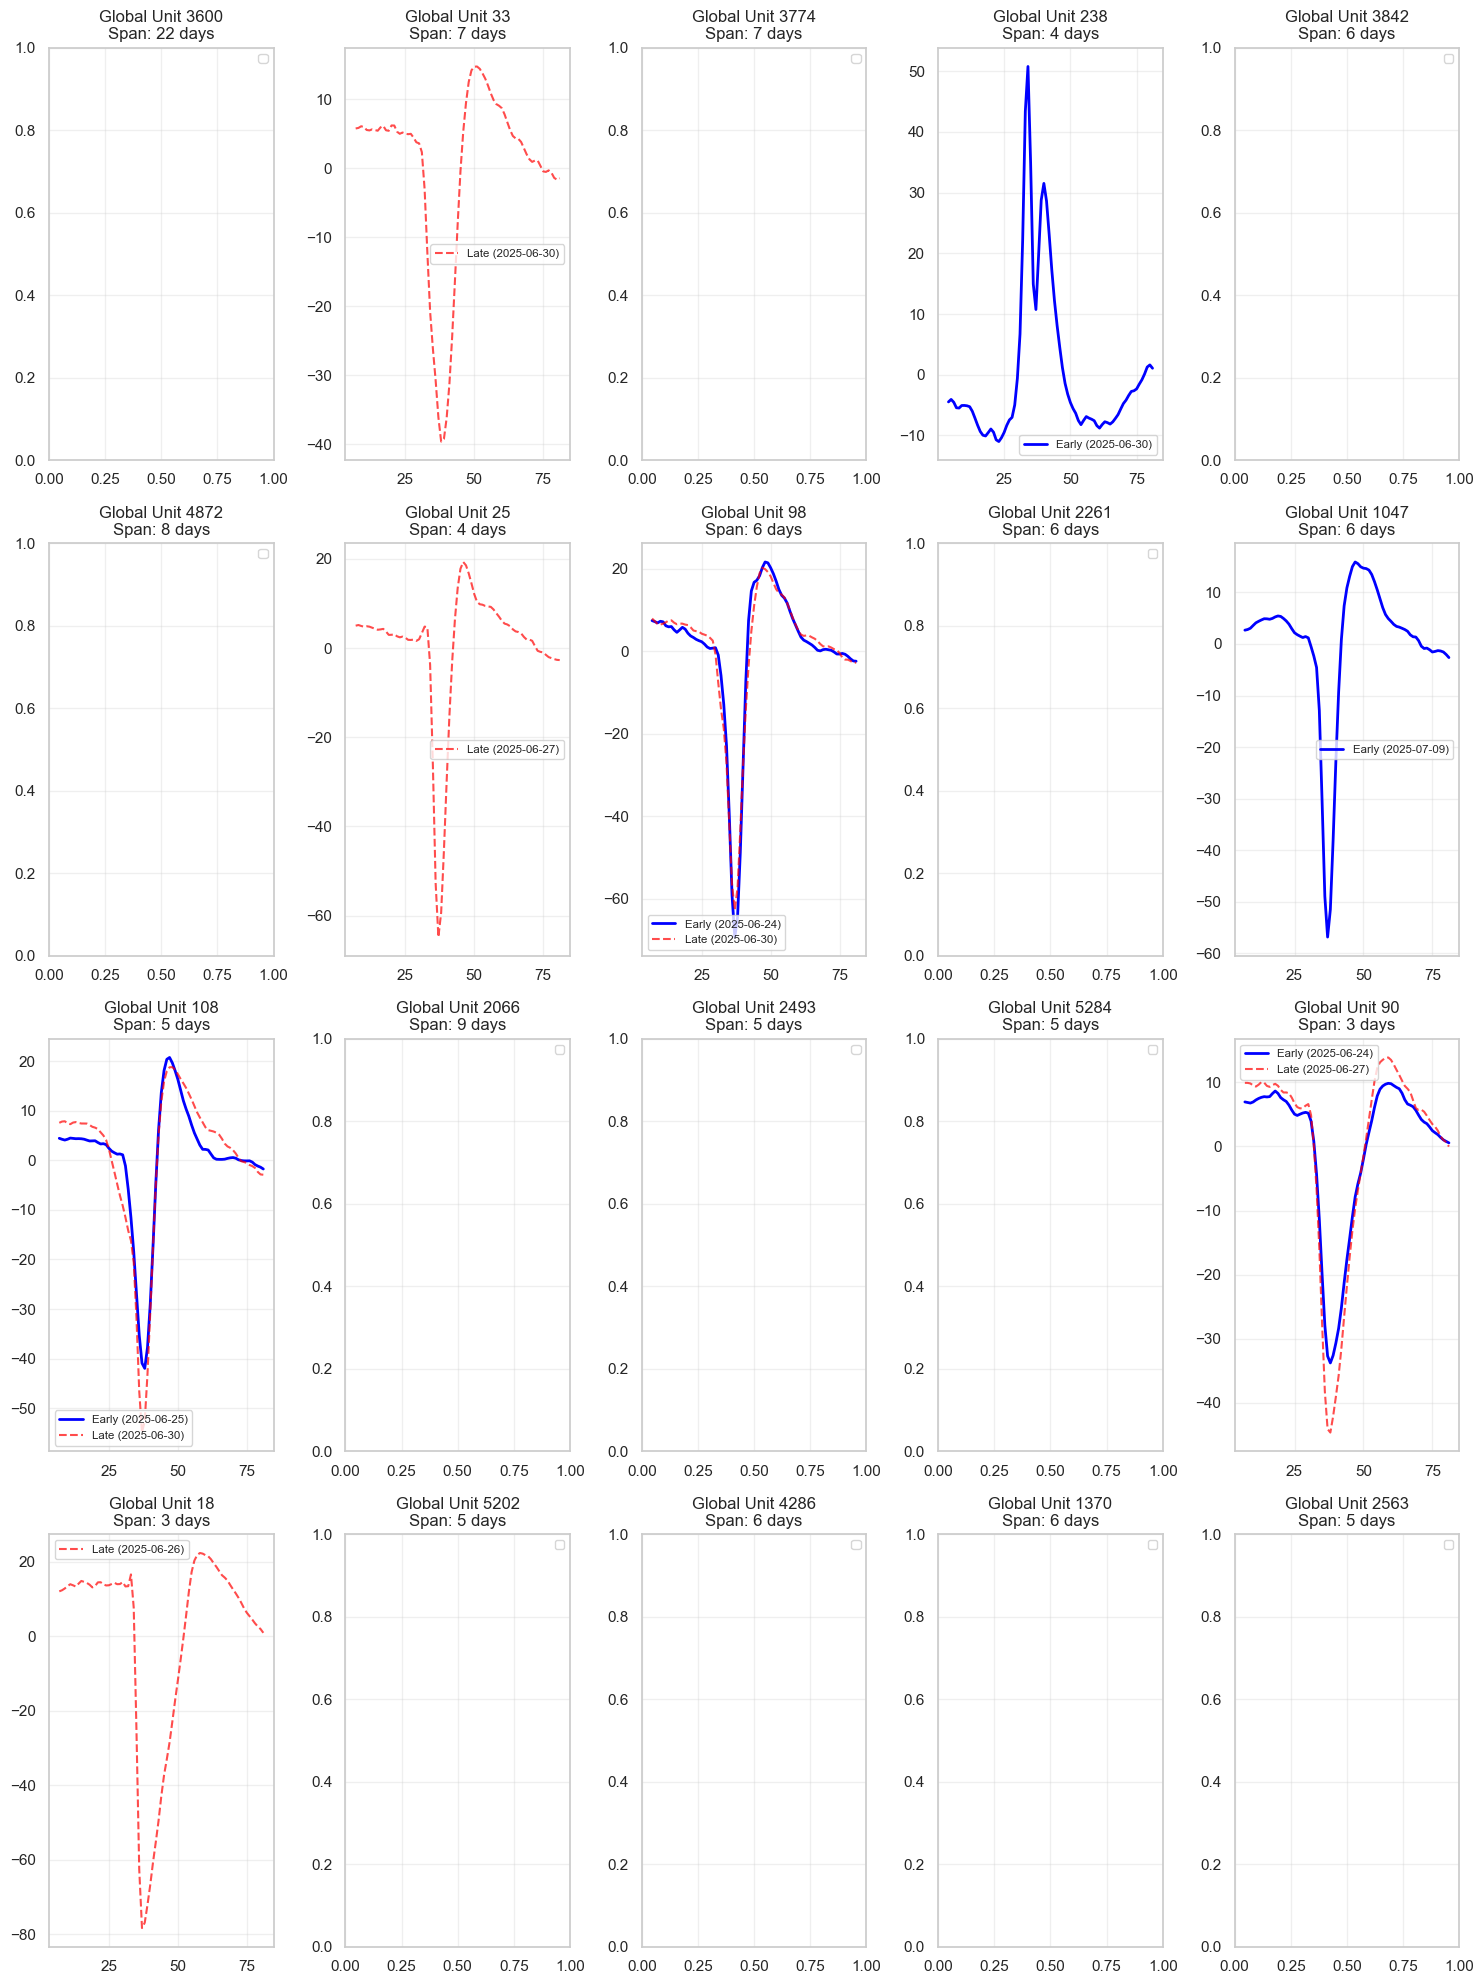

In [10]:
def get_waveform_for_unit(target_date, target_cluster_id, registry_files):
    """
    Finds a batch containing the target_date, looks up the ClusterID, 
    and returns the waveform from WaveformInfo.npz.
    """
    # 1. format date to string DDMMYYYY
    target_col = target_date.strftime("%d%m%Y")
    
    # 2. Search suitable batch
    for p in registry_files:
        # Check if CSV has column (quick check by reading header? or just try/except)
        # We'll read the CSV. Batch size is small (12 cols).
        try:
            # We assume we can cache this or just read. Reading 30 small CSVs is fast enough.
            df = pd.read_csv(p, index_col=0)
            
            if target_col in df.columns:
                # 3. Find Unit
                # Column values are float/int. target_cluster_id is from GlobalRegistry (float).
                # Find row where column value matches cluster id
                match = df[df[target_col] == target_cluster_id]
                
                if not match.empty:
                    batch_uid = match.index[0]
                    
                    # 4. Load Waveform
                    wf_path = p.parent / "WaveformInfo.npz"
                    if not wf_path.exists():
                        continue
                        
                    with np.load(wf_path) as data:
                        # Shape: (Time, Units, Channels?)
                        # Based on inspection: (82, N_Units, 2)
                        # We take the first channel/dim 0 which is typically the mean waveform
                        wfs = data['avg_waveform']
                        if batch_uid < wfs.shape[1]:
                             wave = wfs[:, batch_uid, 0]
                             return wave, p.parent.name
        except:
            continue
            
    return None, None

# Select Top 20 Units
top_20_units = global_registry.loc[global_presence.sort_values(ascending=False).head(20).index]

plt.figure(figsize=(15, 20))

for idx, (global_uid, row) in enumerate(top_20_units.iterrows()):
    # Get valid sessions
    valid_sessions = row.dropna()
    valid_dates = valid_sessions.index # DatetimeIndex
    
    early_date = valid_dates.min()
    late_date = valid_dates.max()
    
    early_id = valid_sessions[early_date]
    late_id = valid_sessions[late_date]
    
    # Retrieve Waveforms
    wf_early, batch_early = get_waveform_for_unit(early_date, early_id, registry_files)
    wf_late, batch_late = get_waveform_for_unit(late_date, late_id, registry_files)
    
    # Plot
    plt.subplot(4, 5, idx+1)
    if wf_early is not None:
        plt.plot(wf_early, label=f"Early ({early_date.strftime('%Y-%m-%d')})", color='blue', linewidth=2)
    if wf_late is not None:
        plt.plot(wf_late, label=f"Late ({late_date.strftime('%Y-%m-%d')})", color='red', alpha=0.7, linestyle='--')
        
    plt.title(f"Global Unit {global_uid}\nSpan: {(late_date - early_date).days} days")
    plt.legend(fontsize='x-small')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Functional Validation: TF Responsiveness
Because Temporal Frequency (TF) responsiveness is a reliable functional signature in the Striatum (likely inputs from Visual Cortex or Motor Cortex), we can use it to validate our tracking.

If a neuron is "TF Responsive" on Day 1, it should likely be "TF Responsive" on Day 10 if we tracked it correctly. We will check this overlap.

**Criteria:**
*   A neuron is **TF Responsive** if `abs(z_score) > 2.0` for any condition (Fast/Slow, Min/Max).
*   Data Source: `FIGURES/tf/BG_046_{Date}/tf_pulse_grid_both.csv`

Building Functional Map for Top 50 Units (Threshold Z > 2.0)...
Done.


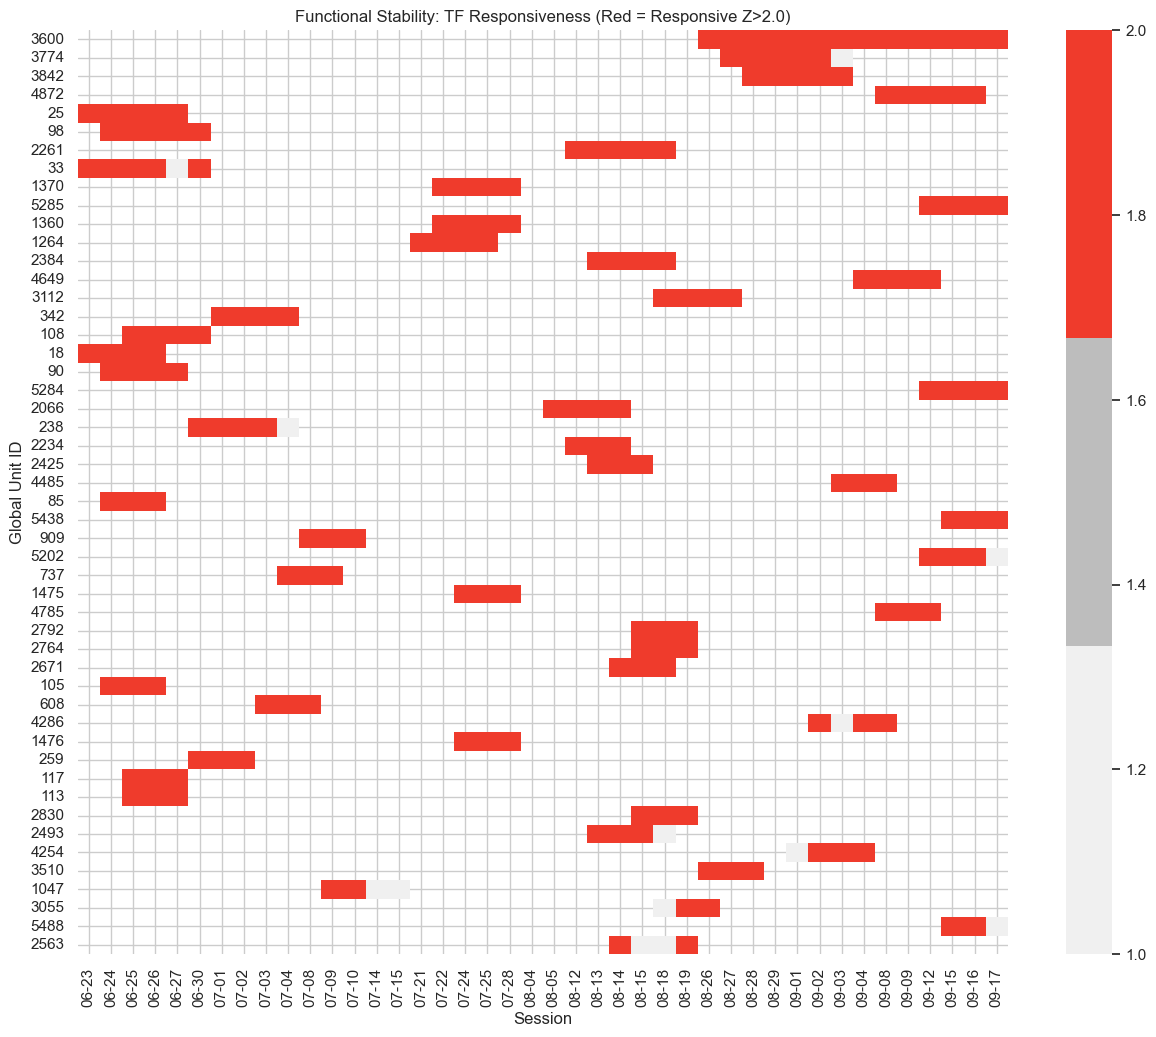

In [11]:
from src.unit_tracking import TFAnalyzer

tf_root = repo_root / "FIGURES" / "tf"

# --- Apply to Top Persistent Neurons ---
top_50_indices = global_presence.sort_values(ascending=False).head(50).index
top_50_units = global_registry.loc[top_50_indices]

# Create Functional Map
functional_map = pd.DataFrame(index=top_50_units.index, columns=top_50_units.columns)

print("Building Functional Map for Top 50 Units (Threshold Z > 2.0)...")
for global_uid, row in top_50_units.iterrows():
    for date_col in top_50_units.columns:
        cluster_id = row[date_col]
        
        if pd.isna(cluster_id):
            functional_map.at[global_uid, date_col] = np.nan 
        else:
            status = TFAnalyzer.get_tf_metric(date_col, cluster_id, tf_root, metric='status')
            functional_map.at[global_uid, date_col] = status

print("Done.")

# --- Visualize ---
plt.figure(figsize=(15, 12))
heatmap_data = functional_map.astype(float)

# Custom Colormap: 0=LightGrey, 1=DarkGrey, 2=Red
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#f0f0f0', '#bdbdbd', '#ef3b2c']) 

# Sort by number of RESPONSIVE sessions
n_responsive = (heatmap_data == 2).sum(axis=1)
heatmap_data = heatmap_data.loc[n_responsive.sort_values(ascending=False).index]

x_labels = [d.strftime("%m-%d") for d in heatmap_data.columns]

sns.heatmap(heatmap_data, cmap=cmap, cbar=True, xticklabels=x_labels)
plt.title("Functional Stability: TF Responsiveness (Red = Responsive Z>2.0)")
plt.xlabel("Session")
plt.ylabel("Global Unit ID")
plt.show()

### B. Onset Analysis
Do TF-responsive neurons appear "suddenly"? Or are they present-but-silent before becoming responsive?


Number of Top 50 Units that show TF Responsiveness: 50


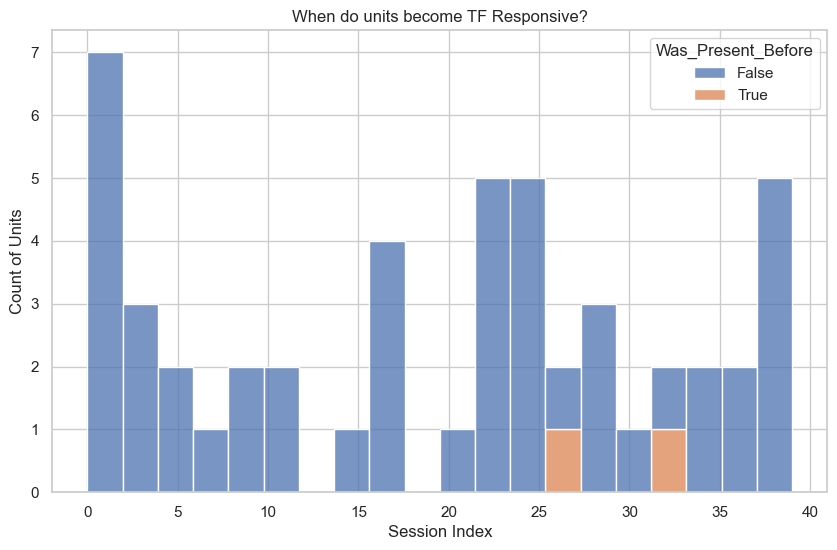

In [12]:
# Analyze transition from "Present" (1) to "Responsive" (2)
# Filter for units that have at least one '2'
responsive_units = heatmap_data[(heatmap_data == 2).any(axis=1)]

print(f"Number of Top 50 Units that show TF Responsiveness: {len(responsive_units)}")

if not responsive_units.empty:
    transitions = []
    
    for idx, row in responsive_units.iterrows():
        # Find first index of '2'
        first_resp_idx = np.where(row.values == 2)[0][0]
        
        # Check if it was present before?
        was_present_before = False
        if first_resp_idx > 0:
            prev_val = row.iloc[first_resp_idx - 1]
            if prev_val == 1:
                was_present_before = True
        
        transitions.append({
            'Global_UID': idx,
            'First_Responsive_Session_Index': first_resp_idx,
            'Was_Present_Before': was_present_before
        })
    
    df_trans = pd.DataFrame(transitions)
    
    # Plot First Appearance of Responsiveness
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_trans, x='First_Responsive_Session_Index', hue='Was_Present_Before', multiple='stack', bins=20)
    plt.title("When do units become TF Responsive?")
    plt.xlabel("Session Index")
    plt.ylabel("Count of Units")
    plt.show()

Extracting raw Z-max values...


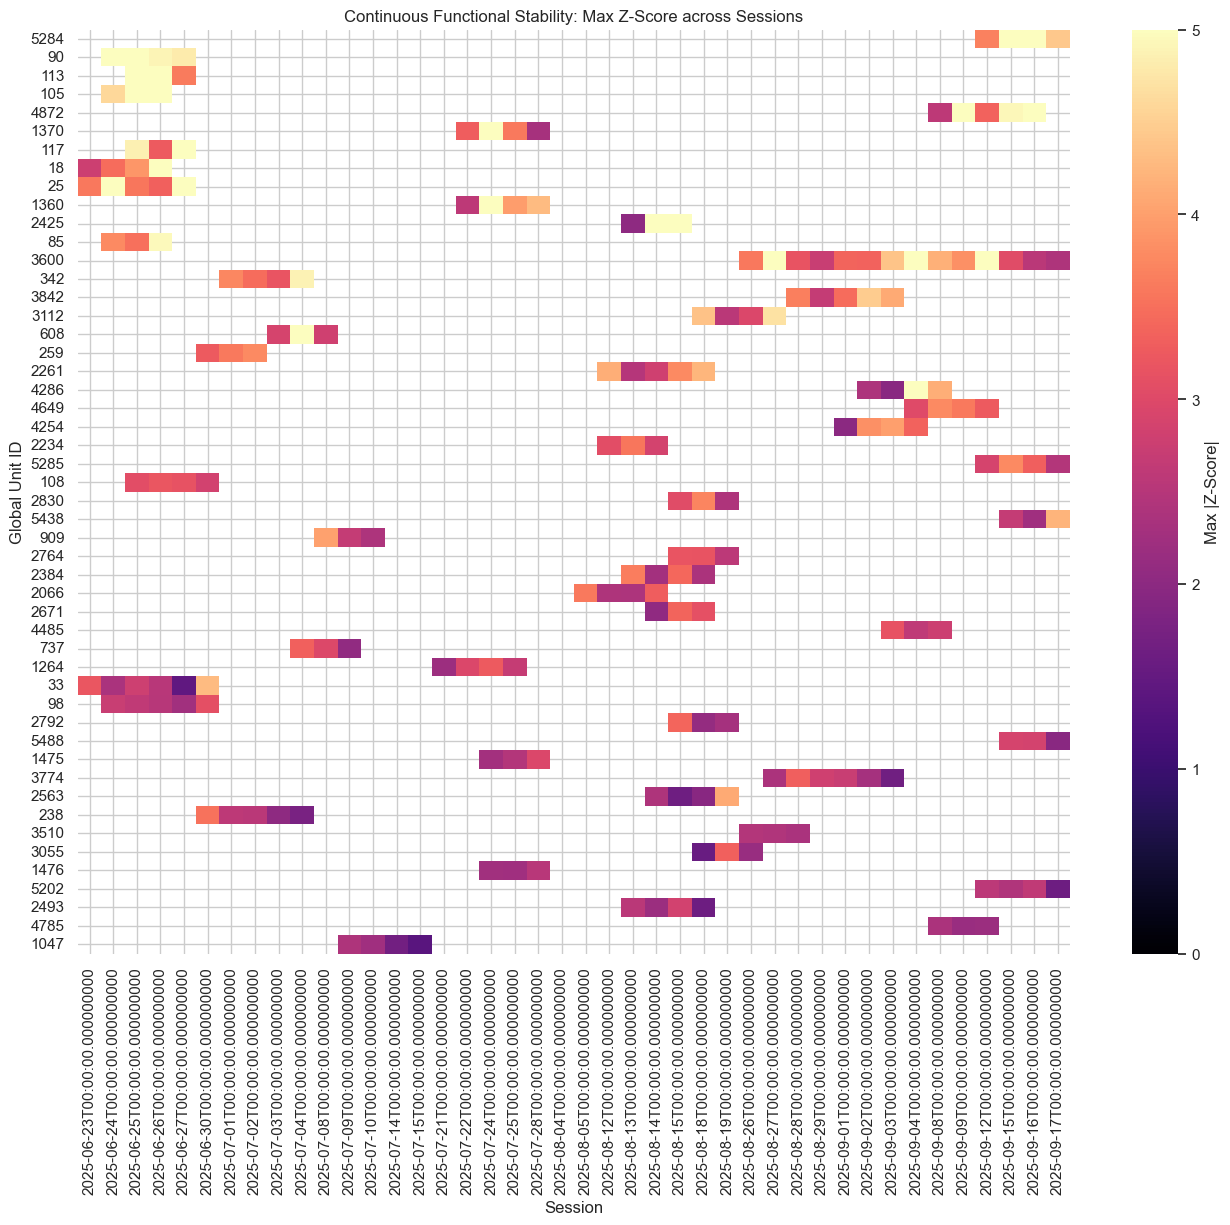

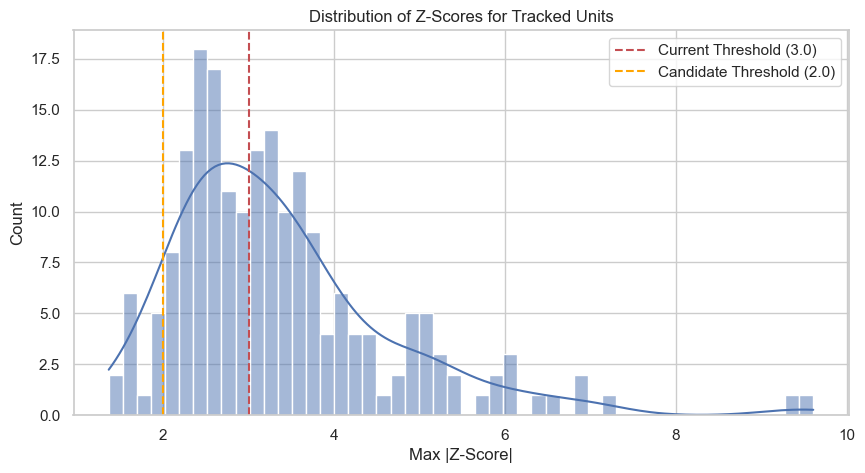

In [13]:
# --- Visualization: Raw Z-Scores (Continuous) ---
# This reveals "weak but stable" responsiveness (e.g. Z ~ 2.0) that the binary mask hides.

print("Extracting raw Z-max values...")

# Build Raw Map
raw_map = pd.DataFrame(index=top_50_units.index, columns=top_50_units.columns)
for global_uid, row in top_50_units.iterrows():
    for date_col in top_50_units.columns:
        cluster_id = row[date_col]
        if pd.isna(cluster_id):
            raw_map.at[global_uid, date_col] = np.nan
        else:
            raw_map.at[global_uid, date_col] = TFAnalyzer.get_tf_metric(date_col, cluster_id, tf_root, metric='raw_z')

raw_map = raw_map.astype(float)

# Sort by Mean Z-score (ignoring NaNs)
mean_z = raw_map.mean(axis=1)
raw_map_sorted = raw_map.loc[mean_z.sort_values(ascending=False).index]

# Plot
plt.figure(figsize=(16, 12))
sns.heatmap(raw_map_sorted, cmap="magma", cbar_kws={'label': 'Max |Z-Score|'}, vmin=0, vmax=5)
plt.title("Continuous Functional Stability: Max Z-Score across Sessions")
plt.xlabel("Session")
plt.ylabel("Global Unit ID")
plt.show()

# Distribution check
flat_z = raw_map.values.flatten()
flat_z = flat_z[~np.isnan(flat_z)]

plt.figure(figsize=(10, 5))
sns.histplot(flat_z, bins=50, kde=True)
plt.axvline(3, color='r', linestyle='--', label='Current Threshold (3.0)')
plt.axvline(2, color='orange', linestyle='--', label='Candidate Threshold (2.0)')
plt.title("Distribution of Z-Scores for Tracked Units")
plt.xlabel("Max |Z-Score|")
plt.legend()
plt.show()

Calculating responsiveness scores for all global units (this may take a minute)...
Top 50 Responders selected. Max Mean-Z: 4.77, Min Mean-Z: 2.49


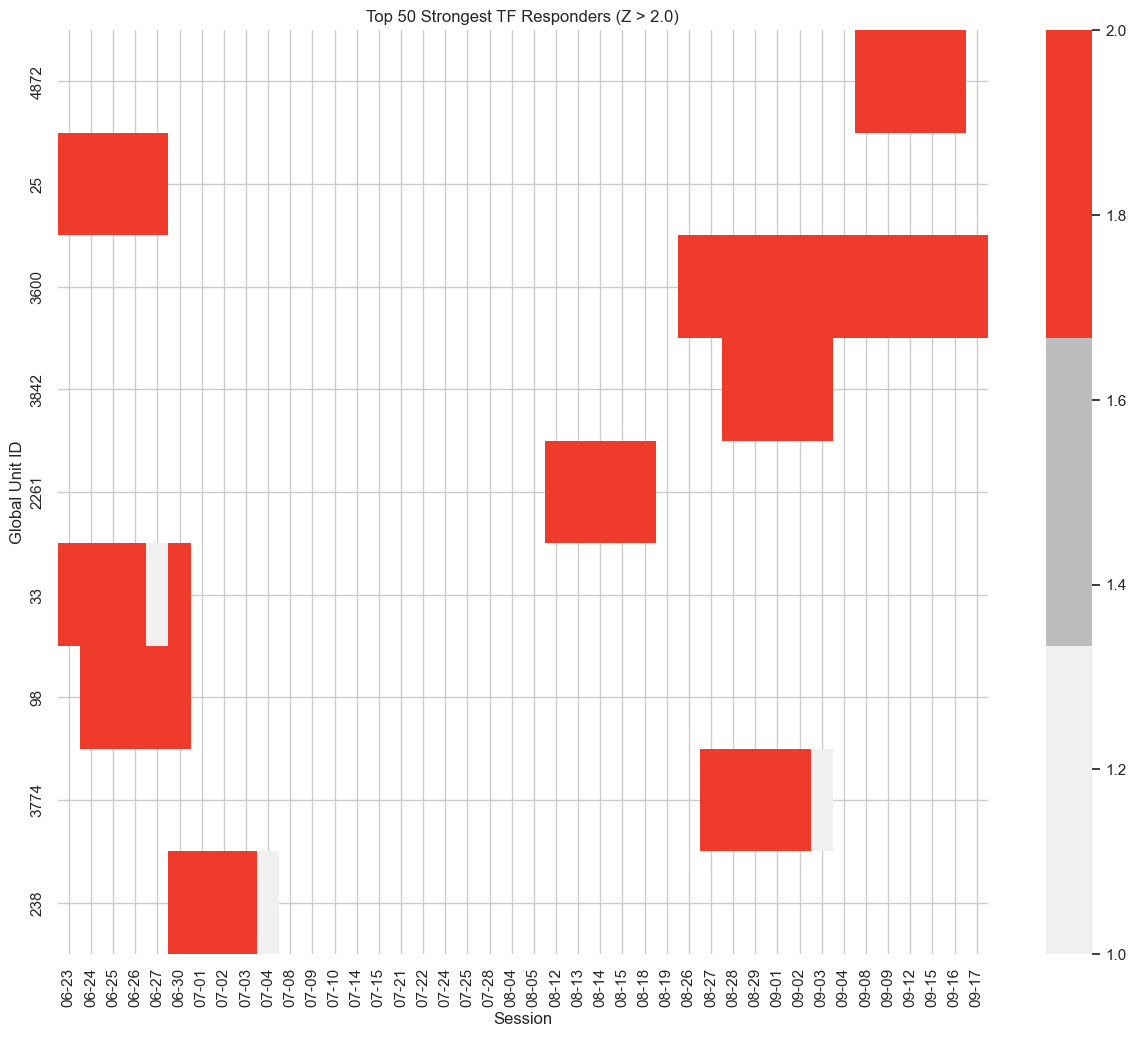

In [14]:
# --- Top 50 Functional Responders ---
# Instead of selecting units by "Persistence" (Tracking Stability), 
# we select them by "Responsiveness" (Average Max Z-Score).
# This highlights the "Best" neurons biologically.

print("Calculating responsiveness scores for all global units (this may take a minute)...")

unit_metrics = []

# Iterate over all units in the registry
for global_uid, row in global_registry.iterrows():
    z_vals = []
    
    # Check valid sessions for this unit
    valid_sessions = row.dropna()
    
    # We enforce a minimum track length to avoid "one-hit wonders" with high noise
    if len(valid_sessions) < 5:
        continue
        
    for date_obj, cluster_id in valid_sessions.items():
        z = TFAnalyzer.get_tf_metric(date_obj, cluster_id, tf_root, metric='raw_z')
        if not np.isnan(z):
            z_vals.append(z)
            
    if z_vals:
        avg_z = np.mean(z_vals)
    else:
        avg_z = 0
        
    unit_metrics.append({
        'Global_UID': global_uid,
        'Mean_Z': avg_z,
        'N_Sessions': len(z_vals)
    })

# Convert to DF and Sort
df_metrics = pd.DataFrame(unit_metrics).set_index('Global_UID')
top_50_responders = df_metrics.sort_values('Mean_Z', ascending=False).head(50)

print(f"Top 50 Responders selected. Max Mean-Z: {top_50_responders['Mean_Z'].max():.2f}, Min Mean-Z: {top_50_responders['Mean_Z'].min():.2f}")

# --- Generate Heatmap for these 50 ---
top_50_resp_units = global_registry.loc[top_50_responders.index]
functional_map_resp = pd.DataFrame(index=top_50_resp_units.index, columns=top_50_resp_units.columns)

for global_uid, row in top_50_resp_units.iterrows():
    for date_col in top_50_resp_units.columns:
        cluster_id = row[date_col]
        
        if pd.isna(cluster_id):
            functional_map_resp.at[global_uid, date_col] = np.nan 
        else:
            status = TFAnalyzer.get_tf_metric(date_col, cluster_id, tf_root, metric='status')
            functional_map_resp.at[global_uid, date_col] = status

# Plot
plt.figure(figsize=(15, 12))
heatmap_data = functional_map_resp.astype(float)

# Use same Red/Gray cmap
x_labels = [d.strftime("%m-%d") for d in heatmap_data.columns]

sns.heatmap(heatmap_data, cmap=cmap, cbar=True, xticklabels=x_labels)
plt.title("Top 50 Strongest TF Responders (Z > 2.0)")
plt.xlabel("Session")
plt.ylabel("Global Unit ID")
plt.show()

In [15]:
# --- 9. Save Verification Metrics ---
# We compile a master list of all Global Units with their tracking and functional stats.
# This "Verified Units" list can be used to filter neurons for downstream analysis (e.g., Learning Curves).

print("Compiling Master Quality Table...")

quality_metrics = []

for global_uid, row in global_registry.iterrows():
    # 1. Tracking Stats
    valid_sessions = row.dropna()
    if valid_sessions.empty:
        continue
        
    start_date = valid_sessions.index.min()
    end_date = valid_sessions.index.max()
    span = (end_date - start_date).days
    n_sessions = len(valid_sessions)
    
    # 2. Functional Stats (if computed in previous cell)
    # df_metrics was created in the "Top 50 Functional Responders" cell
    # It contains Mean_Z for units with >= 5 sessions
    mean_z = np.nan
    if 'df_metrics' in locals() and global_uid in df_metrics.index:
        mean_z = df_metrics.loc[global_uid, 'Mean_Z']
        
    quality_metrics.append({
        'Global_UID': global_uid,
        'Tracking_Total_Sessions': n_sessions,
        'Tracking_Span_Days': span,
        'Tracking_First_Date': start_date,
        'Tracking_Last_Date': end_date,
        'Func_Mean_Z': mean_z,
        'Func_Is_Responsive': (mean_z > 2.0) if not np.isnan(mean_z) else False
    })
    
df_quality = pd.DataFrame(quality_metrics).set_index('Global_UID')

# Filter for "High Quality" candidates
# Criteria for "Official Use":
# 1. Very Persistent: Tracked > 10 sessions
# 2. Functionally Validated: Tracked > 5 sessions AND Strong TF Response (Z > 2.0)
hq_mask = (df_quality['Tracking_Total_Sessions'] >= 10) | \
          ((df_quality['Tracking_Total_Sessions'] >= 5) & (df_quality['Func_Is_Responsive']))
          
print(f"Total Global Units: {len(df_quality)}")
print(f"High Quality Candidates: {hq_mask.sum()}")
print(f"  - Long Track (>10 sessions): {(df_quality['Tracking_Total_Sessions'] >= 10).sum()}")
print(f"  - Verified Responders (>5 sessions, Z>2.0): {((df_quality['Tracking_Total_Sessions'] >= 5) & (df_quality['Func_Is_Responsive'])).sum()}")

# Export to DeepUnitMatch output folder
save_path_q = deep_um_root / "Global_Unit_Quality_Metrics.csv"
df_quality.to_csv(save_path_q)
print(f"\nSaved Full Quality Metrics to: {save_path_q}")

# Save the subset of "Verified" high quality units for easy loading in other scripts
save_path_hq = deep_um_root / "Verified_Global_Units.csv"
df_quality[hq_mask].to_csv(save_path_hq)
print(f"Saved Verified Unit List (Subset) to: {save_path_hq}")

Compiling Master Quality Table...
Total Global Units: 5971
High Quality Candidates: 9
  - Long Track (>10 sessions): 1
  - Verified Responders (>5 sessions, Z>2.0): 9

Saved Full Quality Metrics to: E:\python_analysis\git_repos\vis_detect_analysis_Sep2025\data\deep_unit_match\output\BG_046\Global_Unit_Quality_Metrics.csv
Saved Verified Unit List (Subset) to: E:\python_analysis\git_repos\vis_detect_analysis_Sep2025\data\deep_unit_match\output\BG_046\Verified_Global_Units.csv


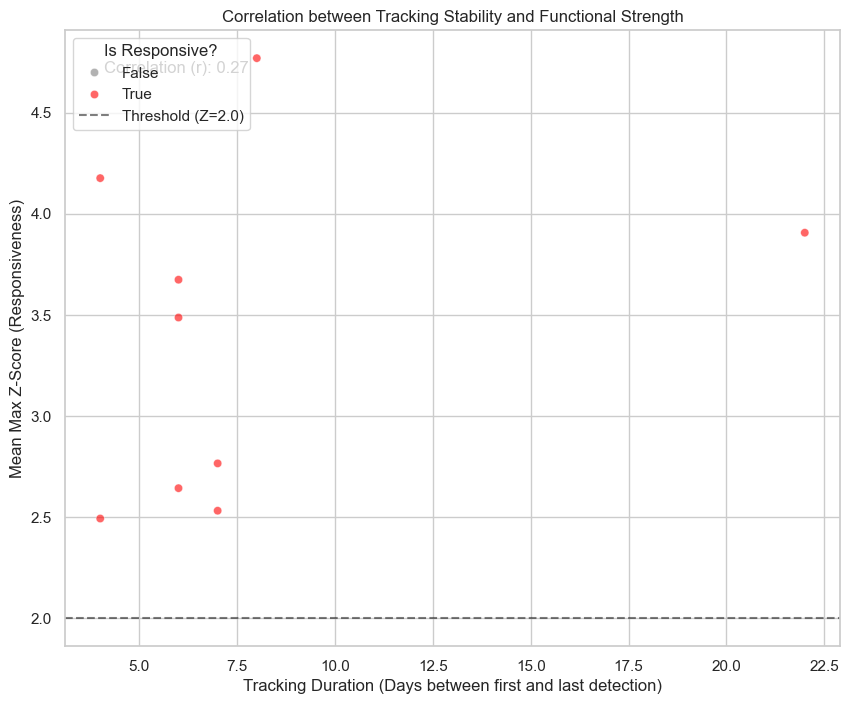

In [16]:
# --- 10. Visualization: Quality vs Quantity ---
# Do neurons that are tracked longer tend to be more responsive?
# Or are the "stable" neurons just the high firing rate ones?

plt.figure(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    data=df_quality, 
    x='Tracking_Span_Days', 
    y='Func_Mean_Z', 
    hue='Func_Is_Responsive',
    alpha=0.6,
    palette={True: 'red', False: 'grey'}
)

plt.title("Correlation between Tracking Stability and Functional Strength")
plt.xlabel("Tracking Duration (Days between first and last detection)")
plt.ylabel("Mean Max Z-Score (Responsiveness)")
plt.axhline(2.0, color='black', linestyle='--', alpha=0.5, label='Threshold (Z=2.0)')
plt.legend(title="Is Responsive?", loc='upper left')

# Add correlation coefficient
subset = df_quality.dropna(subset=['Tracking_Span_Days', 'Func_Mean_Z'])
if len(subset) > 1:
    corr = subset['Tracking_Span_Days'].corr(subset['Func_Mean_Z'])
    plt.text(0.05, 0.95, f"Correlation (r): {corr:.2f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.show()